# IND320- Project Work Part 1
**Student:** Sania Minaipour

## Links
- GitHub repository: https://github.com/Saniami/IND320-project
- Streamlit app:

## AI Usage 
AI tools (Claude) were used throughout this project as a support tool. In the notebook, AI helped me with troubleshooting the Python environment setup, and with figuring out why the plots looked inconsistent, which turned out to be because the dataset mixes several reservoir areas together. For the Streamlit app, AI was used to help write and structure the code for the multi-page setup and the data table with LineChartColumn. I reviewed and tested the code against the actual dataset, made decisions about the design (for example, filtering to Area 4 and how to handle the different scales in the combined plot), and adjusted the code where needed before including it in the final submission.

## Data import  

In [2]:
# Import required libraries for data handling and plotting
import pandas as pd
import matplotlib.pyplot as plt

# Read the reservoirs dataset from CSV
df = pd.read_csv("../data/reservoirs.csv")

# Quick check of the data's shape and first five rows
print(f"Shape: {df.shape}")
df.head()

Shape: (14877, 11)


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Renaming headers from norwegian to english 

In [3]:
# Rename columns from Norwegian to English names
df = df.rename(columns={
    "dato_Id": "Date",
    "omrType": "Area_Type",
    "omrnr": "Area_Number",
    "iso_aar": "ISO_Year",
    "iso_uke": "ISO_Week",
    "fyllingsgrad": "Fill_Percentage",
    "kapasitet_TWh": "Capacity_TWh",
    "fylling_TWh": "Fill_TWh",
    "neste_Publiseringsdato": "Next_Publication_Date",
    "fyllingsgrad_forrige_uke": "Fill_Percentage_Previous_Week",
    "endring_fyllingsgrad": "Fill_Percentage_Change",
})

# Convert Date column to proper datetime type
df["Date"] = pd.to_datetime(df["Date"]) # Convert the 'Date' column from a string to a datetime object 

df.head()

,Date,Area_Type,Area_Number,ISO_Year,ISO_Week,Fill_Percentage,Capacity_TWh,Fill_TWh,Next_Publication_Date,Fill_Percentage_Previous_Week,Fill_Percentage_Change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Print Contents in a relevant way

In [4]:
# Print basic info about the dataset
print(f"Number of rows: {df.shape[0]}")  # Total number of rows in the dataset
print(f"Number of columns: {df.shape[1]}")  # Total number of columns in the dataset
print(f"\nColumn data types:\n{df.dtypes}")  # Data type of each column (e.g. date, number, text)
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")  # Earliest and latest date in the dataset
print(f"\nUnique areas: {df['Area_Number'].unique()}")  # All unique area numbers present in the dataset

df.describe()  # Statistical summary (mean, min, max, etc.) for all numeric columns

Number of rows: 14877
Number of columns: 11

Column data types:
Date                             datetime64[us]
Area_Type                                   str
Area_Number                               int64
ISO_Year                                  int64
ISO_Week                                  int64
Fill_Percentage                         float64
Capacity_TWh                            float64
Fill_TWh                                float64
Next_Publication_Date                       str
Fill_Percentage_Previous_Week           float64
Fill_Percentage_Change                  float64
dtype: object

Date range: 1995-01-08 00:00:00 to 2026-09-06 00:00:00

Unique areas: [4 1 3 5 2 0]


,Date,Area_Number,ISO_Year,ISO_Week,Fill_Percentage,Capacity_TWh,Fill_TWh,Fill_Percentage_Previous_Week,Fill_Percentage_Change
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385


## Plot each column separately

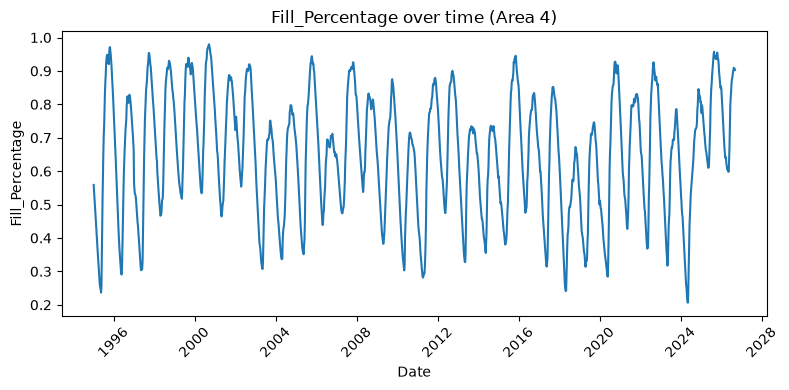

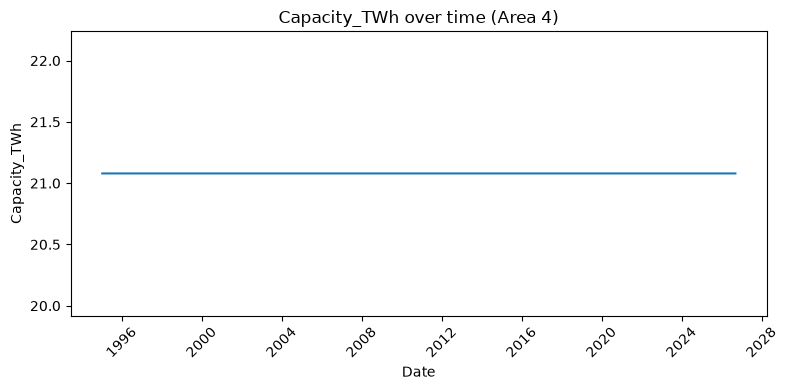

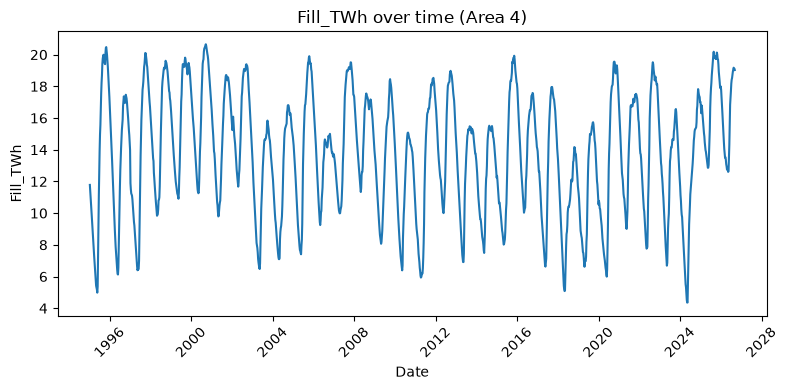

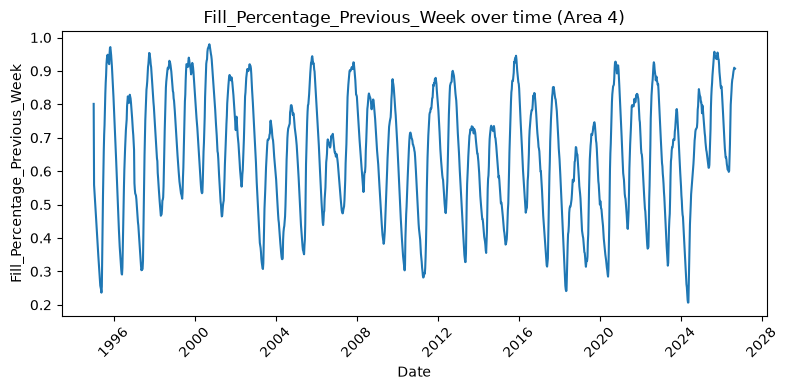

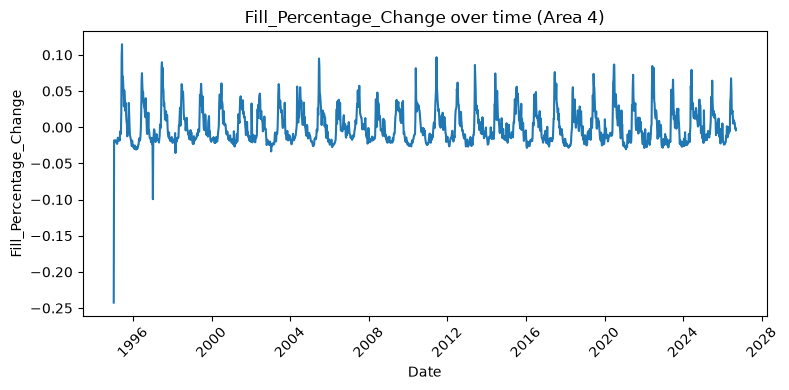

In [5]:
# Filter to a single area for clean time series plotting (data has multiple areas per date)
#Filter to a single area(area 4) for clean time series plotting (data has multiple areas per date)
selected_area = df["Area_Number"].iloc[0]
area_df = df[df["Area_Number"] == selected_area].sort_values("Date")


# List of numeric columns to plot
numeric_cols = ["Fill_Percentage", "Capacity_TWh", "Fill_TWh", 
                 "Fill_Percentage_Previous_Week", "Fill_Percentage_Change"]

# Plot each numeric column separately over time
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.plot(area_df["Date"], area_df[col])
    plt.title(f"{col} over time (Area {area_df['Area_Number'].iloc[0]})")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Plot all columns together

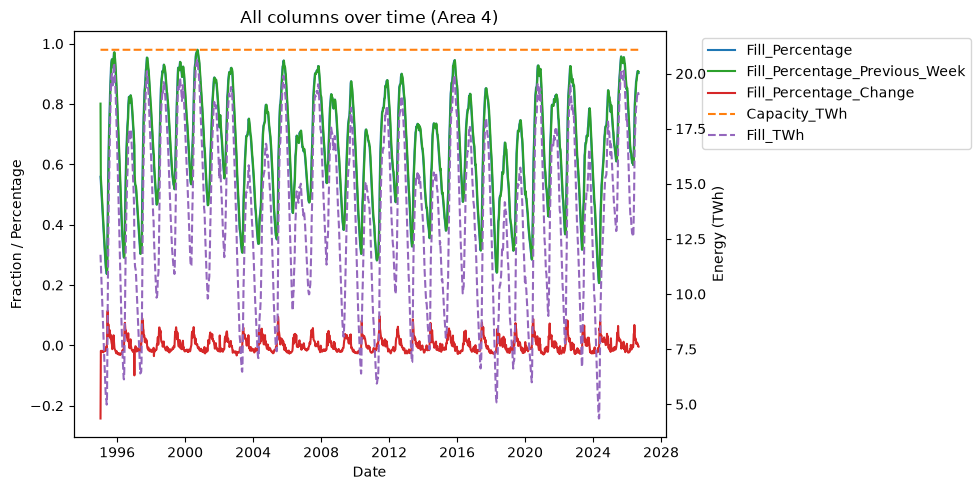

In [ ]:
# Since columns have different units/scales (percentages vs. TWh values),
# use two y-axes (twin axes) instead of normalizing: percentage-based columns 
# on the left axis, TWh-based columns on the right axis. This shows the actual 
# values in their original units, instead of artificially rescaling everything to 0-1.
percentage_cols = ["Fill_Percentage", "Fill_Percentage_Previous_Week", "Fill_Percentage_Change"]
twh_cols = ["Capacity_TWh", "Fill_TWh"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

colors_pct = ["tab:blue", "tab:green", "tab:red"]
colors_twh = ["tab:orange", "tab:purple"]

# Plot percentage-based columns on the left axis
lines = []
for col, color in zip(percentage_cols, colors_pct):
    line, = ax1.plot(area_df["Date"], area_df[col], label=col, color=color)
    lines.append(line)

# Plot TWh-based columns on the right axis
for col, color in zip(twh_cols, colors_twh):
    line, = ax2.plot(area_df[Ø"Date"], area_df[col], label=col, color=color, linestyle="--")
    lines.append(line)

# Labels and title
ax1.set_xlabel("Date")
ax1.set_ylabel("Fraction / Percentage")
ax2.set_ylabel("Energy (TWh)")
ax1.set_title(f"All columns over time (Area {area_df['Area_Number'].iloc[0]})")

# Combine legends from both axes into a single legend
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Log

This project had two parts: exploring the reservoir data in a Jupyter Notebook, and 
rebuilding the same idea as an interactive Streamlit app. Most of what I learned came 
from things not working the first time.

My first problem was the setup. My virtual environment had been created with the wrong 
Python installation, so packages would not install. Recreating it with a standard 
Windows Python fixed it.

The bigger surprise came from the data. After renaming the columns to English, I plotted 
them and the lines jumped up and down instead of showing smooth trends. I talked with 
some fellow students, and they had run into the same problem with their plots, which 
helped me realise that the issue was probably in the data and not in my code. Looking at 
the raw rows, I found that reservoirs.csv mixes several reservoir areas in one file, and 
that it is not sorted by date. I was plotting different areas as if they were one 
continuous series. Printing the unique area numbers in the notebook is what made this 
visible. After filtering to a single area (Area 4) and sorting by date, clear seasonal 
curves appeared.

Choosing Area 4 is a simplification, and it applies to both the notebook and the app. 
The app does not show the full picture across all reservoir areas. A natural next step 
would be letting the user choose the area, or showing all areas as separate, labeled 
series.

The "plot all columns together" task made me think about scales. Fill percentage is 
between 0 and 1, while capacity and fill volume are in TWh. Min-max normalization 
solves the scale problem, but you lose the real values, so in the app I used two y-axes 
instead. I also noticed that some columns add little when plotted together: Fill_TWh is 
basically Fill_Percentage times a constant capacity, and Capacity_TWh does not change 
within one area. Fill_Percentage_Change is left out of the combined plot because it can 
be negative and measures a change rather than a level, but it can still be selected on 
its own in the dropdown.

In Streamlit, the new parts for me were LineChartColumn for the mini charts in the 
table and select_slider for choosing months. Getting the slider to actually filter the 
plot, with the first month as the default, took some trial and error. Using 
@st.cache_data also helped me understand that Streamlit reruns the whole script every 
time a widget changes.

The main lesson was to look at the raw data before trusting any plot. When a graph looks 
strange, the problem is often in the data and not in the code.